In [9]:
''' *** Quantitative calculations for Environmental score (35% of ESG final industry score) ***
1. Data cleaning for each metric across all companies
2. Calculate metric performance per employee per year
3. Split into 10 quantiles and assign score (from 1 to 10) for each metric based on percentile
    1 - 10th percentile: 1, 11 - 20th percentile: 2, ..., 91 - 100th percentile: 10
4. Calculate weighted average environmental score for each company
'''
### All datasets
import pandas as pd
import numpy as np
from scipy.stats import pearsonr


env = pd.read_excel('C:/Users/Lenovo/Desktop/DSS5105/projects/Pioneer DS project.xlsx', sheet_name='Environment')
social = pd.read_excel('C:/Users/Lenovo/Desktop/DSS5105/projects/Pioneer DS project.xlsx', sheet_name='Social')



# Data cleaning
env.rename(columns={'EnergyConsumption(MWh)': 'Energy',
                    'GHG Emissions(tonne (Mt) of CO2e)': 'GHG',
                    'WaterUsage(tonne (Mt))' : 'Water',
                    'WasteGenerated (tonne)' : 'Waste',
                    'RenewableEnergyUse (MWh)' :'Renewable'}, inplace=True)

metric = env.columns[2:]
for col in metric:
    env[col] = env[col].astype(str)
    if env[col].str.contains(',').any():
         env[col] = env[col].str.replace(',', '')
    env[col] = env[col].replace('na', np.nan)
    env[col] = env[col].replace('na', pd.NA)
env[metric] = env[metric].astype(float)


social['EmployeeCount'] = social['EmployeeCount'].astype(str).str.replace(',', '')
pax = social[['CompanyID', 'EmployeeCount', 'ReportYear']].copy()
pax.dropna(inplace=True)
pax['EmployeeCount'] = pax['EmployeeCount'].astype(float).astype(int)


# Calculate metric performance per employee
env_data = pd.merge(pax, env, how='inner', on=['CompanyID', 'ReportYear'])
for col in metric:
    env_data[col + "_per_employee"] = env_data[col] / env_data['EmployeeCount']

# Metric Score calculation        
def calc_score(perf_metric):
    perf_metric.dropna(inplace=True)
    percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    percentile_values = perf_metric.quantile([p / 100 for p in percentiles]).values
    
    def score_value(value):
        for i in range(len(percentile_values) - 1):
            if percentile_values[i] <= value < percentile_values[i + 1]:
                return 10-i
        return 1 if value == percentile_values[-1] else 10

    return perf_metric.apply(score_value)

# Env score calculation
for col in metric:
    env_data[col + "_score"] = calc_score(env_data[col + '_per_employee'])
env_data.fillna(0, inplace=True)
yearly_env_data = env_data.groupby('ReportYear').value_counts().reset_index()
yearly_env_data.drop(columns='count', inplace=True)

# Penalise metric if not reported
env_weights = [0.25, 0.15, 0.15, 0.15, 0.3]
final_env_score = yearly_env_data[['ReportYear', 'CompanyID', 'Energy_score', 'Water_score', 'GHG_score', 'Waste_score', 'Renewable_score']].copy()
env_indicator_score = final_env_score[['Energy_score', 'Water_score', 'GHG_score', 'Waste_score', 'Renewable_score']]
environmental_score = (env_indicator_score * env_weights).sum(axis=1)
final_env_score['Average Environmental Score'] = environmental_score
final_env_score[["Water_score", "Waste_score", "Renewable_score"]] = final_env_score[["Water_score", "Waste_score", "Renewable_score"]].astype(int)
final_env_score.sort_values(by=['CompanyID', 'ReportYear'], inplace = True)
print(final_env_score)


''' *** Quantitative calculations for Social score (45% of ESG final industry score) ***
1. Split into 2 different categories: 
    - Discrete metrics (binary 1, score 10: disclosure; binary 0, score 0: no disclosure)
    Define set of key words to search for:
    a) Data security
        - Data security
        - Data protection 
    b) Customer privacy
        - Privacy protection
        - Consumer protection
        - Customer protection
    c) Cybersecurity
        - Malware 
        - Phishing
        - Network security
        - Information security
        - Cybersecurity
        - Cyberattack
        
    d) Gender diversity metrics
    e) Age-based diversity metrics 
        # both (d) and (e) have statistics reported under diversity and inclusion table: 1, else 0
        
    - Continuous metrics (work-related fatalities, training hours) -> same quantitative scoring system as Env
    
2. Calculate weighted average social score for each company
    - Each metric is then converted to a score from 1 to 10 based on percentile (continuous),
        or a score of 0 or 10 for disclosure (discrete)
'''

# sample data format for social.csv imported above
social_data = pd.DataFrame({
    'CompanyID': [1,2,2,3,4,4,5,6],
    'ReportYear': [2023,2022,2023,2023,2022,2023,2022,2023],
    "Keyword: Data security": [1,1,1,1,0,0,0,0],
    "Keyword: Customer privacy": [1,1,0,0,1,1,0,0],
    "Keyword: Cybersecurity": [1,0,1,0,1,0,1,0],
    "Gender diversity metric": [0,1,0,1,0,1,0,1],
    "Age-based diversity metric": [0,0,1,1,0,1,1,0], # binary -> 0: no disclosure, 1: disclosure
    "Work-related Fatalies/ Injuries recorded (%)": [10,2,3,0.4,3.8,1,20,13], # see if want to split into sub metrics
    "Development and training (training hours)": [100,200,300,400,500,600,700,800]
})

binary_col = social_data.columns[2:7]
social_data[binary_col] = social_data[binary_col] * 10 # score of 10 for disclosure, 0 for no disclosure
continuous_col = social_data.columns[7:].to_list() # continuous metrics
social_data.fillna(0, inplace=True)

# Assign scores for continuous metrics
for col in continuous_col:
    social_data[col + "_score"] = calc_score(social_data[col])

# Weighted average social score
social_weights = [0.2,0.2,0.2,0.1,0.1,0.1,0.1]
yearly_social_data = social_data.groupby(['ReportYear'])[['CompanyID', 'Work-related Fatalies/ Injuries recorded (%)_score', 
                                                         "Development and training (training hours)_score"]].value_counts().reset_index()
yearly_social_data.drop(columns='count', inplace=True)
social_data.merge(yearly_social_data, on=['CompanyID', 'ReportYear'], how='left')

social_indicator_score = social_data[['Keyword: Data security', 'Keyword: Customer privacy', 'Keyword: Cybersecurity',
              "Gender diversity metric", "Age-based diversity metric", 
              'Work-related Fatalies/ Injuries recorded (%)_score', 
              "Development and training (training hours)_score"]]
final_social_score = (social_indicator_score * social_weights).sum(axis=1)
social_data['Average Social Score'] = final_social_score
social_data.drop(columns = ['Work-related Fatalies/ Injuries recorded (%)', 
                            "Development and training (training hours)"], inplace=True)
social_data.sort_values(by=['CompanyID', 'ReportYear'])
print(social_data)


''' *** Quantitative calculations for Governance score (20% of ESG final industry score) ***
1. Discrete metrics (binary 0/1, score of 0 or 10 for disclosure)
    Define set of key words to search for:
    a) Ethical behaviour (30%)
        - Ethics
        - Compliance
        - Anti-corruption
        - Anti-bribery
        - Transparency
    b) Board composition (15%)
        - Board committee
        - Board composition
        - Board independence
    c) Risk management (30%)
        - Risk management
        - Risk oversight
        - Risk assessment
    d) Certifications List (5% each, 25% total)
        - ISO 14001
        - ISO 50001
        - ISO 45001
        - ISO 14064
        - Carbon trust
2. Calculate weighted average governance score for each company
'''

# sample data format for governance.csv (to be imported above)
gov_data = pd.DataFrame({
    'CompanyID': [1,2,2,3,4,4,5,6],
    'ReportYear': [2023,2022,2023,2023,2022,2023,2022,2023],
    "Keyword: Ethical behaviour": [1,1,1,1,0,0,0,0],
    "Keyword: Board Composition": [1,1,0,0,1,1,0,0],
    "Keyword: Risk management": [1,0,1,0,1,0,1,0],
    "Certification list": [0,1,4,1,5,2,3,3] # Score 10/10: all certifications awarded, : none awarded
})

gov_col = gov_data.columns[2:]
gov_keyword = gov_data.columns[2:5]
certificate = gov_data.columns[5]
gov_data.fillna(0, inplace=True)
gov_data[gov_keyword] = gov_data[gov_keyword] * 10 # scores for main keywords
gov_data[certificate] = gov_data[certificate] * 2 # scores for certifications

# Weighted average governance score
gov_weights = [0.3, 0.15, 0.3, 0.25]
gov_indicator_score = gov_data.iloc[:,2:]
final_gov_score = (gov_indicator_score * gov_weights).sum(axis=1)
gov_data['Average Governance Score'] = final_gov_score
gov_data.sort_values(by=['CompanyID', 'ReportYear'])
print(gov_data)

### Final ESG score calculation
esg_score = pd.concat([gov_data, social_data, final_env_score], axis=1)
esg_score['Final ESG score'] = (esg_score['Average Governance Score'] * 0.2 
                                 + esg_score['Average Social Score'] * 0.45
                                + esg_score['Average Environmental Score'] * 0.35)

    ReportYear  CompanyID  Energy_score  Water_score  GHG_score  Waste_score  \
0       2019.0        1.0             2            5          5            3   
4       2020.0        1.0             1            6          8            2   
11      2021.0        1.0             1            5         10            2   
19      2022.0        1.0             1            5          9            1   
27      2023.0        1.0             1            4          9            2   
1       2019.0        2.0             9            8          6            0   
5       2020.0        2.0            10            8          7            3   
12      2021.0        2.0             9            7          7            4   
20      2022.0        2.0             9            9          6            4   
28      2023.0        2.0             8            8          6            4   
6       2020.0        3.0            10            7          7            8   
13      2021.0        3.0            10 

In [12]:
import statsmodels.api as sm


# 假设有一个DataFrame存放了公司的财务数据
financial_data = pd.DataFrame({
    'CompanyID': [1,2,2,3,4,4,5,6],
    'ReportYear': [2023,2022,2023,2023,2022,2023,2022,2023],
    'Operating Profit Margin (%)': [15, 10, 12, 20, 8, 15, 9, 14],  # 营业利润率
    'Gross Profit Margin (%)': [30, 28, 32, 25, 20, 27, 22, 26],  # 毛利率
    'Net Profit Margin (%)': [12, 8, 10, 18, 6, 10, 7, 12],  # 净利润率
    'ROA (%)': [10, 8, 9, 15, 5, 12, 6, 11],  # 总资产回报率
    'ROE (%)': [18, 15, 17, 20, 12, 18, 14, 19]  # 净资产回报率
})

# 将财务数据与ESG评分合并
esg_score_unique = esg_score.loc[:, ~esg_score.columns.duplicated()]
esg_financial_data = pd.merge(esg_score_unique[['CompanyID', 'ReportYear', 'Final ESG score']], 
                              financial_data, on=['CompanyID', 'ReportYear'], how='inner')


# 定义自变量（财务指标）和因变量（ESG score）
X = esg_financial_data[['Operating Profit Margin (%)', 'Gross Profit Margin (%)', 
                        'Net Profit Margin (%)', 'ROA (%)', 'ROE (%)']]
y = esg_financial_data['Final ESG score']

# 添加常数项（截距项）
X = sm.add_constant(X)

# 使用 OLS 进行回归
model = sm.OLS(y, X).fit()

# 输出完整的回归结果表
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:        Final ESG score   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     13.79
Date:                Thu, 10 Oct 2024   Prob (F-statistic):             0.0690
Time:                        17:06:35   Log-Likelihood:                 1.5528
No. Observations:                   8   AIC:                             8.894
Df Residuals:                       2   BIC:                             9.371
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

d:\Python\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=8 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [13]:
# 单独提取并展示 p 值
p_values = model.pvalues
print("\nP-values for each variable:")
print(p_values)

# 判断每个变量是否线性相关（p < 0.05 被认为有显著线性关系）
significance_level = 0.05
linear_correlation = p_values < significance_level
print("\nIs there a significant linear correlation (p < 0.05)?")
print(linear_correlation)


P-values for each variable:
const                          0.036031
Operating Profit Margin (%)    0.104798
Gross Profit Margin (%)        0.018078
Net Profit Margin (%)          0.336611
ROA (%)                        0.450626
ROE (%)                        0.024461
dtype: float64

Is there a significant linear correlation (p < 0.05)?
const                           True
Operating Profit Margin (%)    False
Gross Profit Margin (%)         True
Net Profit Margin (%)          False
ROA (%)                        False
ROE (%)                         True
dtype: bool


In [14]:
print(esg_score.columns)

Index(['CompanyID', 'ReportYear', 'Keyword: Ethical behaviour',
       'Keyword: Board Composition', 'Keyword: Risk management',
       'Certification list', 'Average Governance Score', 'CompanyID',
       'ReportYear', 'Keyword: Data security', 'Keyword: Customer privacy',
       'Keyword: Cybersecurity', 'Gender diversity metric',
       'Age-based diversity metric',
       'Work-related Fatalies/ Injuries recorded (%)_score',
       'Development and training (training hours)_score',
       'Average Social Score', 'ReportYear', 'CompanyID', 'Energy_score',
       'Water_score', 'GHG_score', 'Waste_score', 'Renewable_score',
       'Average Environmental Score', 'Final ESG score'],
      dtype='object')


Company 1 ESG Score Forecast:
   Year  Predicted ESG Score
0  2024                  7.2
1  2025                  7.2
2  2026                  7.2
3  2027                  7.2
4  2028                  7.2



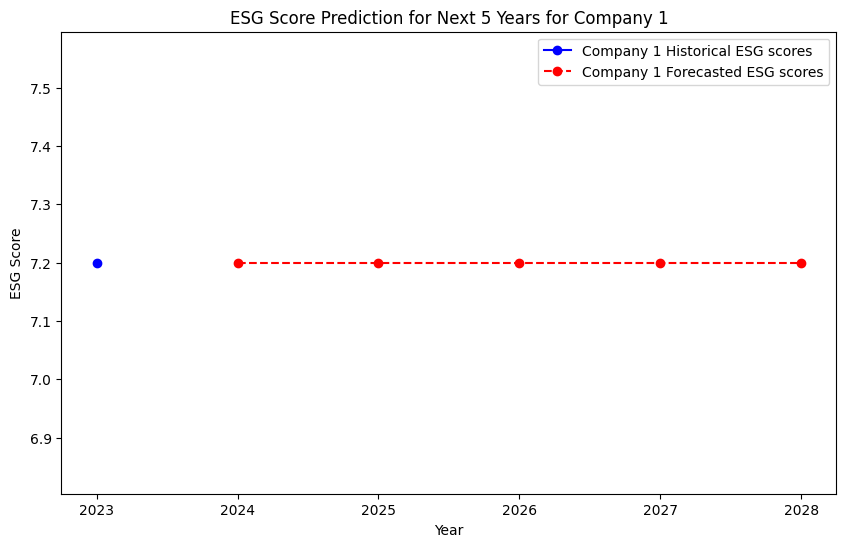

Company 2 ESG Score Forecast:
   Year  Predicted ESG Score
2  2024             6.500025
3  2025             6.000029
4  2026             5.500034
5  2027             5.000038
6  2028             4.500043



d:\Python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


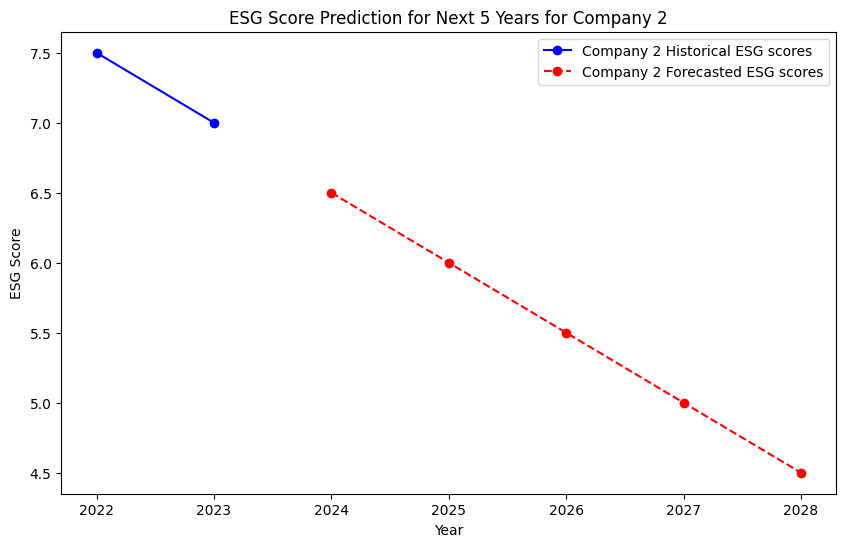

Company 3 ESG Score Forecast:
   Year  Predicted ESG Score
0  2024                  7.8
1  2025                  7.8
2  2026                  7.8
3  2027                  7.8
4  2028                  7.8



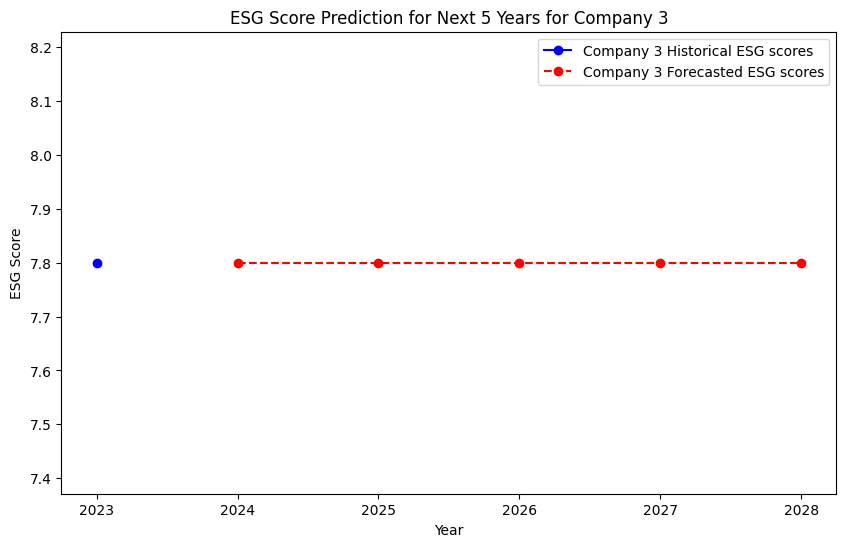

Company 4 ESG Score Forecast:
   Year  Predicted ESG Score
2  2024             7.599990
3  2025             7.899988
4  2026             8.199986
5  2027             8.499985
6  2028             8.799983



d:\Python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


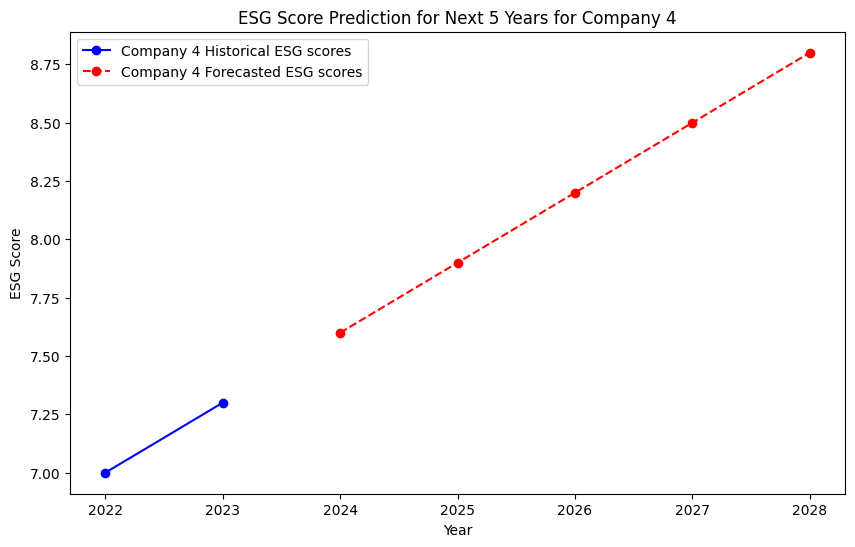

Company 5 ESG Score Forecast:
   Year  Predicted ESG Score
0  2023                  7.9
1  2024                  7.9
2  2025                  7.9
3  2026                  7.9
4  2027                  7.9



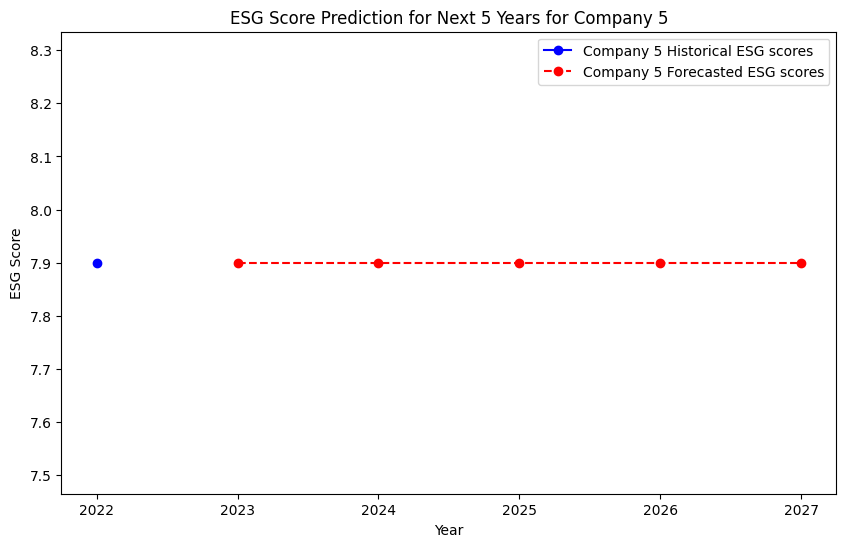

Company 6 ESG Score Forecast:
   Year  Predicted ESG Score
0  2024                  6.9
1  2025                  6.9
2  2026                  6.9
3  2027                  6.9
4  2028                  6.9



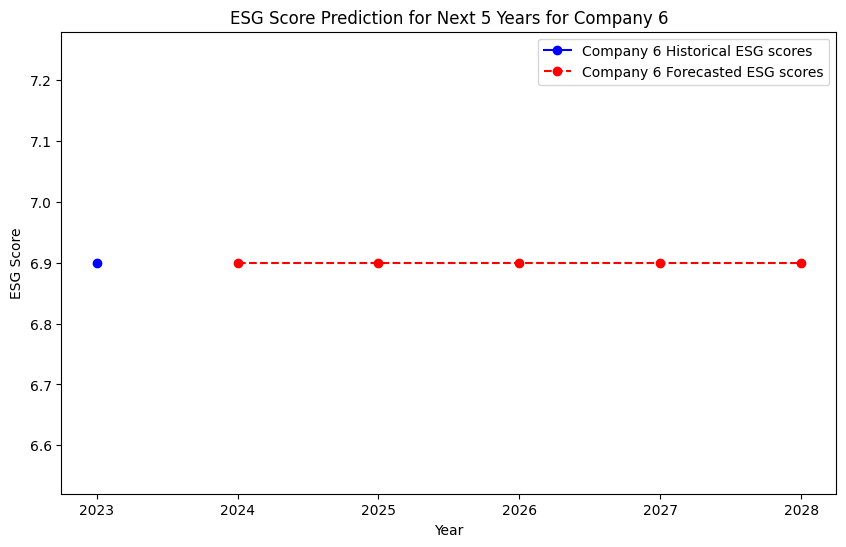

In [16]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# 假设 esg_score 是含有公司编码、年份和 ESG 分数的 DataFrame
data = {
    'CompanyID': [1, 2, 2, 3, 4, 4, 5, 6],
    'ReportYear': [2023, 2022, 2023, 2023, 2022, 2023, 2022, 2023],
    'Final ESG score': [7.2, 7.5, 7.0, 7.8, 7.0, 7.3, 7.9, 6.9]
}

esg_score = pd.DataFrame(data)

# 保留所需列
esg_ts_data = esg_score[['CompanyID', 'ReportYear', 'Final ESG score']].copy()

# 确保 'CompanyID' 是普通列，去除索引影响
esg_ts_data.reset_index(drop=True, inplace=True)

# 设置预测的年份数
forecast_years = 5

# 对每家公司分别进行预测
company_forecasts = {}

# 对每个公司分别建立指数平滑模型和预测
for company_id, group in esg_ts_data.groupby('CompanyID'):
    # 确保数据按年份排序，并将年份设置为索引
    group = group.sort_values(by='ReportYear').set_index('ReportYear')

    # 检查该公司有多少年数据
    if len(group) < 2:
        # 数据少于两年，使用均值预测未来
        forecast = [group['Final ESG score'].mean()] * forecast_years
    else:
        # 使用指数平滑法进行时间序列预测
        model = ExponentialSmoothing(group['Final ESG score'], trend="add", seasonal=None, initialization_method="estimated")
        model_fit = model.fit()

        # 预测未来3年
        forecast = model_fit.forecast(steps=forecast_years)

    # 预测未来3年的年份列表
    last_year = group.index[-1]
    future_years = [last_year + i for i in range(1, forecast_years + 1)]

    # 将预测结果保存到字典中
    forecast_df = pd.DataFrame({'Year': future_years, 'Predicted ESG Score': forecast})
    company_forecasts[company_id] = forecast_df

    # 打印每个公司的预测结果
    print(f"Company {company_id} ESG Score Forecast:")
    print(forecast_df)
    print()

    # 可视化预测结果
    plt.figure(figsize=(10, 6))
    plt.plot(group.index, group['Final ESG score'], color='blue', marker='o', label=f'Company {company_id} Historical ESG scores')
    plt.plot(forecast_df['Year'], forecast_df['Predicted ESG Score'], color='red', marker='o', linestyle='--', label=f'Company {company_id} Forecasted ESG scores')
    plt.xlabel('Year')
    plt.ylabel('ESG Score')
    plt.title(f'ESG Score Prediction for Next {forecast_years} Years for Company {company_id}')
    plt.legend()
    plt.show()
